# Prepare 2012 Kauring AirGrav ASEG-GDF2 data

**__See EastVic Data for latest organisation of Prepare tutorials__**

This short tutorial demonstrates the preparation of ASEG-GDF2 data for QC review.

We need all the data in HDF5 geoWhizz format because all the QC functions expect that format. (More on the geoWhizz format elsewhere in the __pe*ga*susQC__ documentation.)

For this example we are using the data from the Kauring airborne gravity survey flown by SGL in 2012.

This step is reasonably straightforward and once complete, the QC of the data should proceed quickly and smoothly, and the outputs will be clearly documented so that the JupyterLab notebook can serve as the QC report.

___

**Import modules and set filenames**

In [1]:
from pathlib import Path

import pegasusQC  as qc

In [2]:
dx = Path(r'./Kauring_grv/GRAV.DAT')

___

**2012 Kauring Gravimeter Survey**

`asegToHDF` does all the work. You must specify the channel containing the line number so that it can organise the data by flight-line. Optionally, you can also supply the channels containing the flight number, and date (not present in the 2012 Kauring data), and a list of channels you do not want copied across to the geowhizz HDF file.

In [3]:
# asegToHdf fails if the file exists so delete it if it does. CHECK
if dx.with_suffix('.hdf5').exists(): 
    dx.with_suffix('.hdf5').unlink()

In [4]:
dh = qc.asegToHDF(Path(dx),
            lineChannel='LINE',
            flightChannel='FLIGHT',
            omitChannels=[],)

No field width found in format code  A4


WARNING - no date channel found.

Key channels for linegroup attributes found:
  LINE at 2, FLIGHT at 3.

36 channels to be written to geoWhizz file: 
['EASTING', 'NORTHING', 'LINE', 'FLIGHT', 'FID', 'SECOND', 'UTCSECOND', 'DAYOFYEAR', 'YEAR', 'LATITUDE', 'LONGITUD', 'GPSZ', 'MSLZ', 'ALT', 'ALTTER', 'BAREEARTHTER', 'DEMTER', 'FZ', 'AZ', 'GRVRAW', 'LATCOR', 'EOTCOR', 'FACOR', 'GRVFRA100S', 'INTCOR', 'GRVFRAL100S', 'FTBCOR_267', 'GRVBGL100S_267', 'GRVFAL0600M', 'GRVFAL1000M', 'GRVBGL0600M_267', 'GRVBGL1000M_267', 'FVDBGL0600M_267', 'FVDBGL1000M_267', 'GNDGRV_FA_UPWARD', 'GNDGRV_BG_UPWARD']
Writing to geoWhizz file: Kauring_grv/GRAV.hdf5
L 10100... count = 1001
L 10200... count = 1013
L 10300... count = 1021
L 10400... count = 970
L 10500... count = 1003
L 10600... count = 1015
L 10700... count = 1027
L 10800... count = 1013
L 10900... count = 1002
L 11000... count = 1025
L 11100... count = 993
L 100100... count = 854
L 100200... count = 869
L 100300... count = 863
L 100400... count = 881


Once the file is created, we can add in the project and block name. These are used in plot titles, keeping the report informative and clear.


In [4]:
block_name = 'Kauring Western Australia SGL 2012'
project_name = 'Kauring Airborne Gravity'
qc.updateProject(dh, acquirer='SGL', projectName=project_name, blockID=block_name)

Setting ProjectName = Kauring Airborne Gravity for GRAV.hdf5.
Setting BlockID = Kauring Western Australia SGL 2012 for GRAV.hdf5.
Setting Acquirer = SGL for GRAV.hdf5.


The CoordFrame metadata provides the names of default channels, and related coordinate information, for the QC functions.

In [5]:
qc.updateCoordFrame(dh, 
                    lat='LATITUDE', 
                    lon='LONGITUD', 
                    x='EASTING', 
                    y='NORTHING', 
                    time='UTCSECOND', 
                    alt='GPSZ', 
                    geoDatum='WGS84', 
                    htDatum='GRS80', 
                    projection='UTM', 
                    utmz='50')

Changed CoordFrame attribute(s) for GRAV.hdf5.


The `line_type` tells `updateLineAttributes` how to extract the planned line number, the segment number, and the repeat number from each reported survey line number. It also allows it to classify flight-lines as traverse or control lines. This information is used by various QC functions.

More details on Line Types can be found elsewhere in the documentation.

In [6]:
qc.updateLineAttributes(dh, line_type='SGL_Kauring')

NO ACTION TAKEN ON LINE_TYPE - no plan file provided.

Setting Line attributes for GRAV.hdf5 according to the SGL_Kauring scheme.


Now we can report the contents of our new geowhizz file.

In [7]:
qc.reportWhizz(dh)

Whizz Version 1.0
    Acquirer: SGL
    BlockID: Kauring Western Australia SGL 2012
    ProjectName: Kauring Airborne Gravity

Coordinates
    AltitudeChannel: GPSZ
    GeoDatum: WGS84
    HeightDatum: GRS80
    LatitudeChannel: LATITUDE
    LongitudeChannel: LONGITUD
    Projection: UTM
    TimeChannel: UTCSECOND
    UTMZone: 50
    XChannel: EASTING
    YChannel: NORTHING
224 lines: total distance flown [km] = 3,106.1

224 lines:
 ['100100', '100200', '100300', '100400', '100500', '100600', '100700', '100800', '100900', '10100', '101000', '101100', '101200', '101300', '101400', '101500', '101600', '101700', '101800', '101900', '10200', '102000', '102100', '102200', '102300', '102400', '102500', '102600', '102700', '102800', '102900', '10300', '103000', '103100', '103200', '103300', '103400', '103500', '103600', '103700', '103800', '103900', '10400', '104000', '104100', '104200', '104300', '104400', '104500', '104600', '104700', '104800', '104900', '10500', '105000', '105100', '105200

The units, and the description, if it exists and is formatted according to the standard, are copied from the DFN file.

In [8]:
qc.reportChannels(dh, verbose=True)

Whizz Version 1.0
  channel              units          description
--------------------------------------------------
  ALT                  m              
  ALTTER               m              
  AZ                   mGal           
  BAREEARTHTER         m              
  DAYOFYEAR                           
  DEMTER               m              
  EASTING              m              
  EOTCOR               mGal           
  FACOR                mGal           
  FID                                 
  FTBCOR_267           mGal           
  FVDBGL0600M_267      Eotvos         
  FVDBGL1000M_267      Eotvos         
  FZ                   mGal           
  GNDGRV_BG_UPWARD     mGal           
  GNDGRV_FA_UPWARD     mGal           
  GPSZ                 m              
  GRVBGL0600M_267      mGal           
  GRVBGL1000M_267      mGal           
  GRVBGL100S_267       mGal           
  GRVFAL0600M          mGal           
  GRVFAL1000M          mGal           
  GRVFRA100S           

In [9]:
qc.reportSampling(dh)

Whizz Version 1.0
    Acquirer: SGL
    BlockID: Kauring Western Australia SGL 2012
    ProjectName: Kauring Airborne Gravity

Sample time and distance statistics
  Min   = -86399.500 s, 16.2 m
  Max   = 0.500 s, 27.8 m
  Mean  = -0.780 s, 23.0 m
  Stdev = 333 s, 2 m


We can check that the traverse and control lines have been correctly classified. We have not asked for a classification on the basis of odd or even line-numbering.

In [10]:
qc.reportLines(dh)

0 even lines, 0 odd lines.
213 traverse lines, 11 control lines, 0 not classified.

 Whizz Version 1.0 

Odd Lines:
 [] 

Even Lines:
 [] 

Traverse Lines:
 ['100100', '100200', '100300', '100400', '100500', '100600', '100700', '100800', '100900', '101000', '101100', '101200', '101300', '101400', '101500', '101600', '101700', '101800', '101900', '102000', '102100', '102200', '102300', '102400', '102500', '102600', '102700', '102800', '102900', '103000', '103100', '103200', '103300', '103400', '103500', '103600', '103700', '103800', '103900', '104000', '104100', '104200', '104300', '104400', '104500', '104600', '104700', '104800', '104900', '105000', '105100', '105200', '105300', '105400', '105500', '105600', '105700', '105800', '105900', '106000', '106100', '106200', '106300', '106400', '106500', '106600', '106700', '106800', '106900', '107000', '107100', '107200', '107300', '107400', '107500', '107600', '107700', '107800', '107900', '108000', '108100', '108200', '108300', '108400', '1

___

**Make a flight-line map**

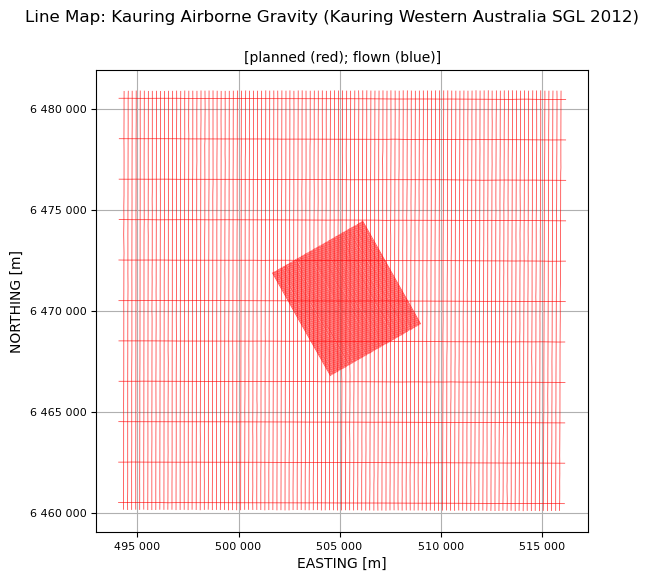

In [11]:
qc.linesMap([dh], whizzPlanFile=dh)